<a href="https://colab.research.google.com/github/Ingur-5967/ml-university/blob/main/ml_prac3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическая работа №3. Библиотека Pandas. Визуальный анализ данных

## Комплексное задание №1. Применение основных методов для анализа данных

1. Скачайте этот блокнот к себе.
2. Заполните пропущенные ячейки, отвечая на заданные вопросы. Там должен быть код! (если не сказано обратное)
3. Сохраните результат в своём гитхаб репозитории.

#### Полезная литература
- [**Блокнот с теорией**](https://colab.research.google.com/drive/1SLqmaYz4xEsxVV-LGwb3ityheBTzHJQu?usp=sharing)
- http://pandas.pydata.org/pandas-docs/stable/10min.html
- https://pandas.pydata.org/pandas-docs/stable/indexing.html
- https://pandas.pydata.org/pandas-docs/stable/missing_data.html

В этом задании мы с Вами рассмотрим датасет [Adult Data Set](https://archive.ics.uci.edu/ml/datasets/Adult).
Основывается он на данных переписи населения 1994 года в США.

Расшифровка содержимого колонок:

- age: continuous.
- workclass: Private, Self-emp-not-inc, Self-emp-inc, Federal-gov, Local-gov, State-gov, Without-pay, Never-worked.
- fnlwgt: continuous. sampling weight, more here: SIPP Weighting.
- education: Bachelors, Some-college, 11th, HS-grad, Prof-school, Assoc-acdm, Assoc-voc, 9th, 7th-8th, 12th, Masters, 1st-4th, 10th, Doctorate, 5th-6th, Preschool.
- education-num: continuous.
- marital-status: Married-civ-spouse, Divorced, Never-married, Separated, Widowed, Married-spouse-absent, Married-AF-spouse.
- occupation: Tech-support, Craft-repair, Other-service, Sales, Exec-managerial, Prof-specialty, Handlers-cleaners, Machine-op-inspct, Adm-clerical, Farming-fishing, Transport-moving, Priv-house-serv, Protective-serv, Armed-Forces.
- relationship: Wife, Own-child, Husband, Not-in-family, Other-relative, Unmarried.
- race: White, Asian-Pac-Islander, Amer-Indian-Eskimo, Other, Black.
- sex: Female, Male.
- capital-gain: continuous. Income from investment sources, apart from wages/salary.
- capital-loss: continuous. Losses from investment sources, apart from wages/salary.
- hours-per-week: continuous.
- native-country: United-States, Cambodia, England, Puerto-Rico, Canada, Germany, Outlying-US(Guam-USVI-etc), India, Japan, Greece, South, China, Cuba, Iran, Honduras, Philippines, Italy, Poland, Jamaica, Vietnam, Mexico, Portugal, Ireland, France, Dominican-Republic, Laos, Ecuador, Taiwan, Haiti, Columbia, Hungary, Guatemala, Nicaragua, Scotland, Thailand, Yugoslavia, El-Salvador, Trinadad&Tobago, Peru, Hong, Holand-Netherlands.

In [ ]:
%matplotlib inline
import pandas as pd
pd.__version__

'2.2.2'

Если вы увидели warning, не переживайте, всё хорошо.
- https://stackoverflow.com/questions/40845304/runtimewarning-numpy-dtype-size-changed-may-indicate-binary-incompatibility
- https://github.com/numpy/numpy/pull/432

In [ ]:
%matplotlib inline
import pandas as pd
columns='age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income'.split(',')
# df = pd.read_csv('../../data/adult.csv.gz', na_values='?') # можно загрузить из файла или URL
df = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data', na_values=' ?', names=columns)
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


1) Выведите последние 10 элеметнов датасета

In [ ]:
df.tail(10)

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
32551,32,Private,34066,10th,6,Married-civ-spouse,Handlers-cleaners,Husband,Amer-Indian-Eskimo,Male,0,0,40,United-States,<=50K
32552,43,Private,84661,Assoc-voc,11,Married-civ-spouse,Sales,Husband,White,Male,0,0,45,United-States,<=50K
32553,32,Private,116138,Masters,14,Never-married,Tech-support,Not-in-family,Asian-Pac-Islander,Male,0,0,11,Taiwan,<=50K
32554,53,Private,321865,Masters,14,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,40,United-States,>50K
32555,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K
32560,52,Self-emp-inc,287927,HS-grad,9,Married-civ-spouse,Exec-managerial,Wife,White,Female,15024,0,40,United-States,>50K


2) Сколько колонок и сколько строк в этом датасете?

In [ ]:
shape = df.shape
print(f'Колонок: {shape[1]}, строк: {shape[0]}')

Колонок: 15, строк: 32561


3) Какие типы данных у элементов этого датасета?

In [ ]:
print(df.dtypes)

age                int64
workclass         object
fnlwgt             int64
education         object
education.num      int64
marital.status    object
occupation        object
relationship      object
race              object
sex               object
capital.gain       int64
capital.loss       int64
hours.per.week     int64
native.country    object
income            object
dtype: object


4) Какие признаки имеют пропуски?

In [ ]:
nulls = df.isnull().sum()
print("Признаки с пропусками: ")
for i in range(df.shape[1]):
  if nulls[i] != 0:
    print(df.columns[i])
print("")
print(nulls)

Признаки с пропусками: 
workclass
occupation
native.country

age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64


/tmp/ipython-input-80266333.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if nulls[i] != 0:


5) Как вы думаете, с чем связаны пропуски этих значение. Напишите развернутый ответ в ячейке ниже.

Ваш ответ: вероятнее всего, во время сбора данных люди просто не указывали данные или из-за того, что забыли указать, или из-за желания остаться анонимным.

6) Какие и сколько различных рабочих классов workclass представлено в выборке?

In [ ]:
# print(df['workclass'].unique())
# print(df['workclass'].nunique())

print(df['workclass'].value_counts())

workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64


7) Какой средний возраст женщин и мужчин?

In [ ]:
print(df.groupby('sex')['age'].mean())

sex
Female    36.858230
Male      39.433547
Name: age, dtype: float64


8) Постройте гистограмму(bar) распределения образования людей (education)

<Axes: xlabel='education'>

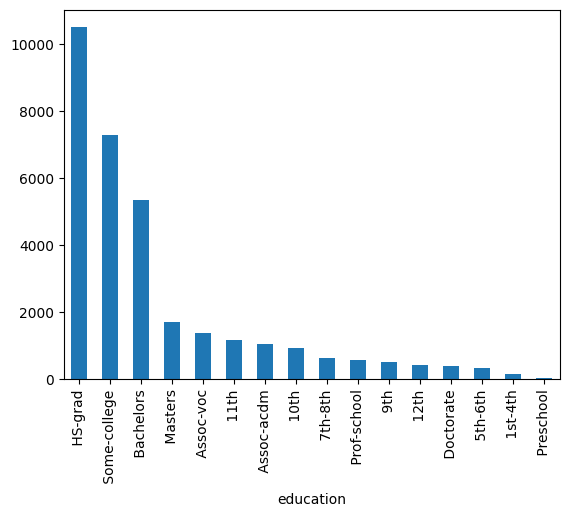

In [ ]:
df['education'].value_counts().plot(kind='bar')

9) Каковы средние значения и среднеквадратичные отклонения возраста тех, кто получает более 50K в год (признак income) и тех, кто получает менее 50K в год?

In [ ]:
stats = df.groupby('income')['age'].describe()
print(f"Среднее значение возраста тех, кто получает <=50K в год: {stats['mean'].iloc[0]}")
print(f"Среднее значение возраста тех, кто получает >50K в год: {stats['mean'].iloc[1]}")
print(f"Среднеквадратичное отклонение возраста тех, кто получает <=50K в год: {stats['std'].iloc[0]}")
print(f"Среднеквадратичное отклонение возраста тех, кто получает >50K в год: {stats['std'].iloc[1]}")
print(stats['mean'], stats['std'])

Средние значения возраста тех, кто получает <=50K в год: 36.78373786407767
Средние значения возраста тех, кто получает >50K в год: 44.24984058155847
Среднеквадратичные отклонения возраста тех, кто получает <=50K в год: 14.020088490824813
Среднеквадратичные отклонения возраста тех, кто получает >50K в год: 10.51902771985177
income
<=50K    36.783738
>50K     44.249841
Name: mean, dtype: float64 income
<=50K    14.020088
>50K     10.519028
Name: std, dtype: float64


10) Правда ли, что люди, которые получают больше 50k, имеют как минимум высшее образование? (признак education - Bachelors, Prof-school, Assoc-acdm, Assoc-voc, Masters или Doctorate)

In [ ]:
high_edu = ['Bachelors', 'Prof-school', 'Assoc-acdm', 'Assoc-voc', 'Masters', 'Doctorate']
count = 0
truec = 0
for i in range(df.shape[0]):
  if (df['income'][i] == " >50K"):
    count += 1
    if df['education'][i][1:] in high_edu: # с помощью [1:] учитываем пробел в начале строк данных...
      truec += 1
print(count, truec)
answer = truec/count
if answer >= 0.5:
  print(f"Правда, {answer}")
else:
  print(f"Ложь, {answer}")

# или же, делаем другим способом: проверяем каждое уникальное образование, и если хоть одно - не высшее, то Ложь.
# df_inc = df[df['income'] == " >50K"]
# flag = True
# for i in df_inc['education'].unique():
#   if i[1:] not in high_edu:
#     print("Ложь")
#     flag = False
#     break
# if flag:
#   print("Правда")

7841 4535
Правда, 0.5783701058538452
Ложь


11) Среди кого больше доля зарабатывающих много (>50K): среди женатых или холостых мужчин (признак marital-status)? Женатыми считаем тех, у кого marital-status начинается с Married (Married-civ-spouse, Married-spouse-absent или Married-AF-spouse), остальных считаем холостыми.

In [ ]:
married = 0
free = 0
for i in range(df.shape[0]):
  if (df['income'][i] ==  " >50K" and df['sex'][i] == " Male"): # как бы странно не выглядело, но пробел в Male обязателен
    if 'Married' in df['marital.status'][i]:
      married += 1
    else:
      free += 1
print("Больше зарабатывающих много...")
if (married > free):
  print(f"Женатых мужчин ({married} женатых, {free} холостых)")
else:
  print(f"Холостых мужчин ({married} женатых, {free} холостых)")

Больше зарабатывающих много...
Женатых мужчин (5965 женатых, 697 холостых)


12) Постройте [сводную таблицу](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.pivot_table.html) для отображения зависимостей среднего времени работы (hours.per.week) с доходом (income) для каждой страны (native.country).  


> Пример фрагмента таблицы:



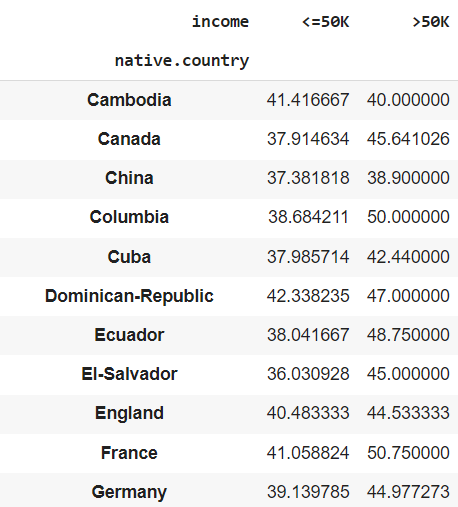

In [ ]:
pd.pivot_table(df, values="hours.per.week", index=["native.country"], columns=["income"], aggfunc="mean")

income,<=50K,>50K
native.country,,
Cambodia,41.416667,40.000000
Canada,37.914634,45.641026
China,37.381818,38.900000
Columbia,38.684211,50.000000
Cuba,37.985714,42.440000
Dominican-Republic,42.338235,47.000000
Ecuador,38.041667,48.750000
El-Salvador,36.030928,45.000000
England,40.483333,44.533333


13) Постройте сводную таблицу для сравнения уровня образования и разности между capital.gain и capital.loss по следующему алгоритму:&nbsp;  
1. Создайте вспомогательную таблицу (датафрейм) и добавьте в неё столбец "education" из целевой таблицы
2. Добавьте во вспомогательную таблицу ещё один столбец "capital.diff", значиниями которого будут являться разности столбцов capital.gain и capital.loss целевой таблицы
3. Удалите во вспомогательной таблице все строки, в которых значение столбца "capital.diff" равно нулю  
&nbsp; Подсказка:
```
summary_table = summary_table[summary_table['capital.diff'] != 0 ]
```
4. Для набора значений из столбца "capital.diff", необходимо сформировать 10 категорий (кластеров), это можно сделать с помощью математических функций, типа log, извлечение корня N-ой степени и округления, для последующего перехода к категориальным признакам.  
  * В нашем случае, можно воспользоваться методом [pd.qcut()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.qcut.html) и равномерно разделить наш набор данных на целевое количество категорий
5. Добавьте во вспомогательную таблицу столбец "categories", и проинициализируйте его значениями категорий, которые возвращает метод pd.qcut()  
&nbsp; Пример:
```
summary_table['categories'] = pd.qcut(summary_table["capital.diff"], q = 10)
```
6. Постройте сводную таблицу с помощью метода pivot_table(),

Примерная структура таблицы (в качестве значений выводится количество людей, относящихся к той или иной группе):

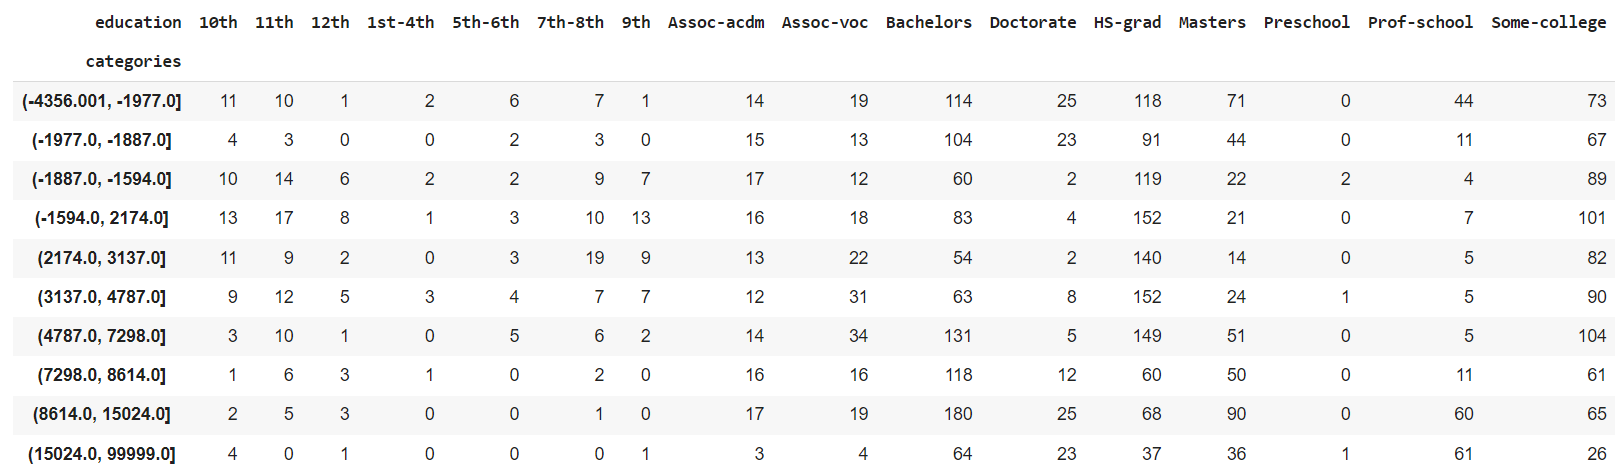

In [ ]:
df1 = pd.DataFrame(df['education'].copy())
df1['capital.diff'] = df['capital.gain'] - df['capital.loss']
df1 = df1[df1['capital.diff'] != 0 ]
df1['categories'] = pd.qcut(df1["capital.diff"], q = 10)
df1.pivot_table(index=["categories"], columns=["education"], aggfunc="size")

/tmp/ipython-input-450/1980530135.py:5: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df1.pivot_table(index=["categories"], columns=["education"], aggfunc="size")


education,10th,11th,12th,1st-4th,5th-6th,7th-8th,9th,Assoc-acdm,Assoc-voc,Bachelors,Doctorate,HS-grad,Masters,Preschool,Prof-school,Some-college
categories,,,,,,,,,,,,,,,,
"(-4356.001, -1977.0]",11,10,1,2,6,7,1,14,19,114,25,118,71,0,44,73
"(-1977.0, -1887.0]",4,3,0,0,2,3,0,15,13,104,23,91,44,0,11,67
"(-1887.0, -1594.0]",10,14,6,2,2,9,7,17,12,60,2,119,22,2,4,89
"(-1594.0, 2174.0]",13,17,8,1,3,10,13,16,18,83,4,152,21,0,7,101
"(2174.0, 3137.0]",11,9,2,0,3,19,9,13,22,54,2,140,14,0,5,82
"(3137.0, 4787.0]",9,12,5,3,4,7,7,12,31,63,8,152,24,1,5,90
"(4787.0, 7298.0]",3,10,1,0,5,6,2,14,34,131,5,149,51,0,5,104
"(7298.0, 8614.0]",1,6,3,1,0,2,0,16,16,118,12,60,50,0,11,61
"(8614.0, 15024.0]",2,5,3,0,0,1,0,17,19,180,25,68,90,0,60,65


14) Женщины из каких стран получают в среднем большую зарплату (>50K) чаще.

In [ ]:
# вопрос - как и что мы считаем за "чаще"?
df_f = df[df['sex'] == ' Female']
df_f['high_income'] = df_f['income'] == ' >50K'
df_f.groupby('native.country')['high_income'].mean().sort_values(ascending=False)

/tmp/ipython-input-427/2044589775.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_f['high_income'] = df_f['income'] == ' >50K'


,high_income
native.country,
Yugoslavia,0.333333
Taiwan,0.266667
France,0.250000
Iran,0.250000
Japan,0.250000
Italy,0.238095
China,0.238095
Canada,0.230769
Greece,0.200000


15) Создайте случайную колонку - magic_salary, которую нужно будет вычислить следующим образом: если зарплата небольшая (<50K), тогда случайно выберите число из диапазона [0,50]. Если зарплата выше 50K тогда из диапазона [51, 200]. Посчитайте среднюю зарплату в час для групп людей с одни уровнем образования на основе нашей случайной колонки magic_salary

In [ ]:
import numpy as np
df['magic.salary'] = 0
for i in range(df.shape[0]):
  if df['income'].iloc[i] == " <=50K":
    df.loc[i, 'magic.salary'] = np.random.randint(0,51)
  else:
    df.loc[i, 'magic.salary'] = np.random.randint(51, 201)
df.groupby('education')['magic.salary'].mean() # это и есть ср. зарплата в час?

,magic.salary
education,
10th,32.574491
11th,29.766809
12th,31.413395
1st-4th,27.297619
5th-6th,28.372372
7th-8th,31.235294
9th,29.978599
Assoc-acdm,49.439550
Assoc-voc,51.160637


## Комплексное задание №2. Визуальный анализ данных. Часть 1

In [34]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
%matplotlib inline

В этом задании Вам предлагается провести визуальный анализ датасета о прокатах велосипедов https://www.kaggle.com/c/bike-sharing-demand/data. Оригинальная задача предполагает построение модели предсказания количества прокатов в городе в зависимости от погоды.

Для каждого дня проката известны следующие признаки (как они были указаны в источнике данных):
- season: 1 - весна, 2 - лето, 3 - осень, 4 - зима
- yr: 0 - 2011, 1 - 2012
- mnth: от 1 до 12
- holiday: 0 - нет праздника, 1 - есть праздник
- weekday: от 0 до 6
- workingday: 0 - нерабочий день, 1 - рабочий день
- weathersit: оценка благоприятности погоды от 1 (чистый, ясный день) до 4 (ливень, туман)
- temp: температура в Цельсиях
- atemp: температура по ощущениям в Цельсиях
- hum: влажность
- windspeed(mph): скорость ветра в милях в час
- windspeed(ms): скорость ветра в метрах в секунду
- cnt: количество арендованных велосипедов (это целевой признак, его мы будем предсказывать)

Загрузите самостоятельно(!), с помощью pandas файл `bikes_rent.csv.gz` и выведите первые 5 строк. Ознакомьтесь с данными с помощью функций describe и info.

In [32]:
# дабы не загружать постоянно файл/загружать его на drive, будем скачивать всегда напрямую
import kagglehub
path = kagglehub.dataset_download("annatrofy/bikes-rent")

df = pd.read_csv('/kaggle/input/bikes-rent/bikes_rent.csv') # если вывел ошибку, запустить еще раз

df.head()

Using Colab cache for faster access to the 'bikes-rent' dataset.


,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed(mph),windspeed(ms),cnt
0,1,0,1,0,6,0,2,14.110847,18.18125,80.5833,10.749882,4.805490,985
1,1,0,1,0,0,0,2,14.902598,17.68695,69.6087,16.652113,7.443949,801
2,1,0,1,0,1,1,1,8.050924,9.47025,43.7273,16.636703,7.437060,1349
3,1,0,1,0,2,1,1,8.200000,10.60610,59.0435,10.739832,4.800998,1562
4,1,0,1,0,3,1,1,9.305237,11.46350,43.6957,12.522300,5.597810,1600


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   season          731 non-null    int64  
 1   yr              731 non-null    int64  
 2   mnth            731 non-null    int64  
 3   holiday         731 non-null    int64  
 4   weekday         731 non-null    int64  
 5   workingday      731 non-null    int64  
 6   weathersit      731 non-null    int64  
 7   temp            731 non-null    float64
 8   atemp           731 non-null    float64
 9   hum             731 non-null    float64
 10  windspeed(mph)  731 non-null    float64
 11  windspeed(ms)   731 non-null    float64
 12  cnt             731 non-null    int64  
dtypes: float64(5), int64(8)
memory usage: 74.4 KB


,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed(mph),windspeed(ms),cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,20.310776,23.717699,62.789406,12.762576,5.705220,4504.348837
std,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,7.505091,8.148059,14.242910,5.192357,2.321125,1937.211452
min,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,2.424346,3.953480,0.000000,1.500244,0.670650,22.000000
25%,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,13.820424,16.892125,52.000000,9.041650,4.041864,3152.000000
50%,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,20.431653,24.336650,62.666700,12.125325,5.420351,4548.000000
75%,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,26.872076,30.430100,73.020850,15.625371,6.984967,5956.000000
max,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,35.328347,42.044800,97.250000,34.000021,15.198937,8714.000000


Давайте посмотрим на графиках, как целевой признак зависит количество прокатов (cnt) зависит от остальных признаков `df.columns[:-1]`.

/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/core.py:896: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="best")
/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/core.py:896: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="best")
/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/core.py:896: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="best")
/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/core.py:896: UserWarning: No artists with labels found to put in legend.  Note that artists whose label sta

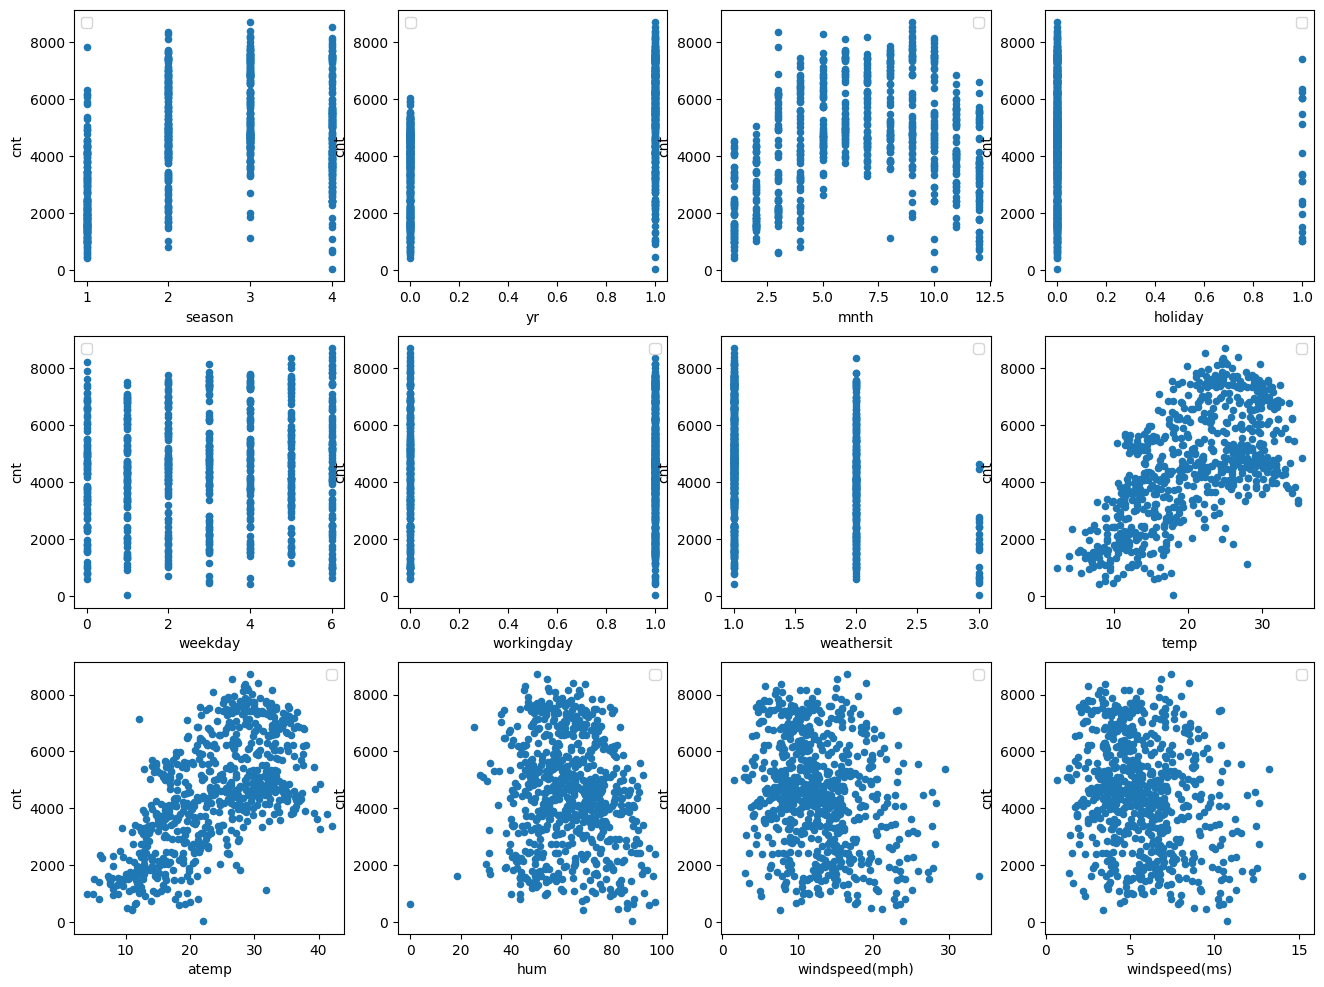

In [35]:
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(16, 12))
for idx, feature in enumerate(df.columns[:-1]):
     df.plot(feature, "cnt", subplots=True, kind="scatter", ax=axes[idx // 4, idx % 4])

### 1. Ответьте на вопросы:

#### Каков характер зависимости числа прокатов от месяца?





Ответ: Зависимость нелинейная. Меньше всего прокатов зимой, тк холодно, больше всего летом, тк тепло

#### Укажите один или два признака, от которых число прокатов скорее всего зависит линейно
_(чем больше значение, тем больше прокатов или наоборот, например)_

Можете проверить результат с помощью lnplot.



Ответ: temp и atemp

### 2. Корреляционная матрица

Напомним, что корреляция отражает взаимосвязь двух случайных величин. Она бывает положительная и отрицательная. Чем ближе коэффициент корреляции к нулю, тем меньше взаимосвязь. Чем больше абсолютная корреляци, тем взаимосвязь больше.

Постройте heatmap корреляционной матрицы. Матрица формируется средствами pandas, со стандартным значением параметров.



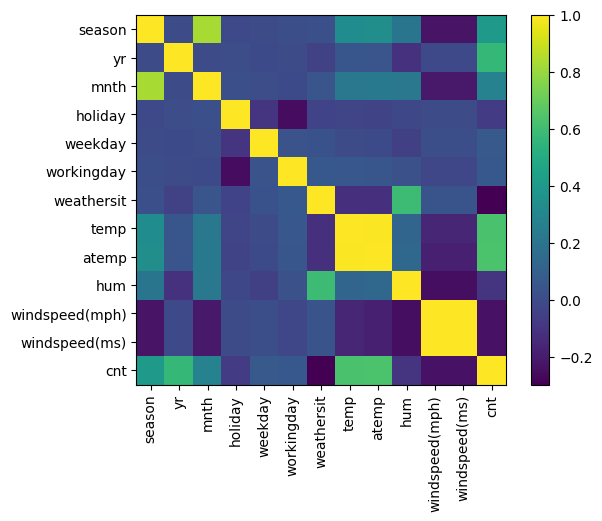

In [36]:
cm = df.corr()
fig, ax = plt.subplots()
im = ax.imshow(cm)
ax.set_xticks([i for i in range(13)])
ax.set_yticks([i for i in range(13)])
ax.set_xticklabels(df.columns, rotation='vertical')
ax.set_yticklabels(df.columns)
ax.figure.colorbar(im, ax=ax)
plt.show()

**Ответьте на вопрос**: с какими признаками количество прокатов коррелирует меньше всего (около 4 штуки). А с какими больше всего?

 Ответ: Меньше вcего с windspeed,weathersit,holiday и hum. Больше всего c yr, temp/atemp,mnth,season

### 3. Barpot

Постройте Bar-график суммарного количества прокатов велосипедов по месяцам за каждый год одновременно. (будет 24 столбика)



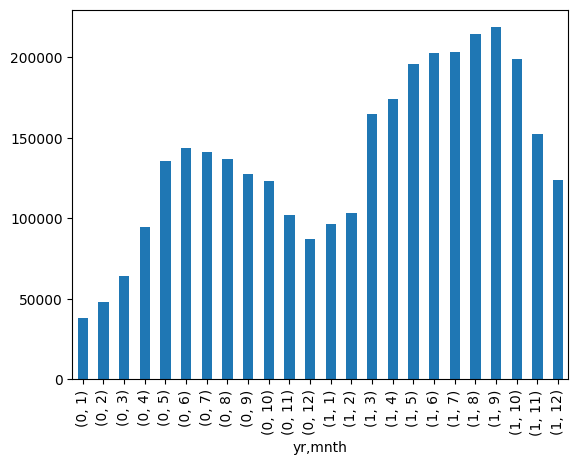

In [37]:
df.groupby(['yr', 'mnth'])['cnt'].sum().plot(kind='bar')
plt.show()

**Ответьте на вопрос:** почему в предыдущем графике была такая большая корреляция между количеством прокатов и годом?

Ответ: Всего два возможных значения, из которых 1 занимала больше всего (скорее всего в 2012 году прокат стал более популярным, чем в 2011)

### 4. Countplot

Постройте countplot диаграммы для признаков `weekday`, `weathersit`,



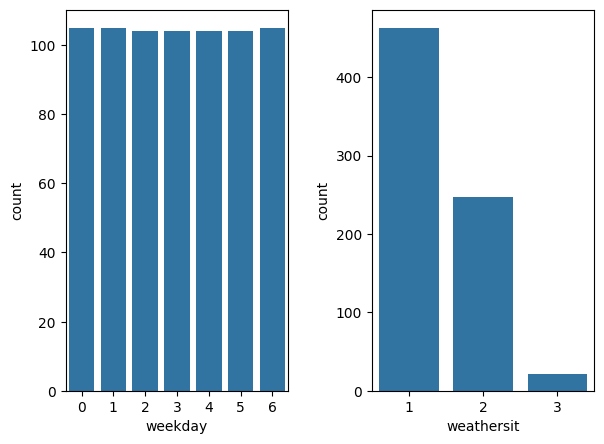

In [38]:
fig, axs = plt.subplots(1, 2)
sns.countplot(data=df, x='weekday', ax=axs[0])
sns.countplot(data=df, x='weathersit', ax=axs[1])
fig.tight_layout(pad=2.0)
plt.show()

**Ответьте на вопрос:** что вы можете сказать о том, как формировался этот датасет.



Ответ: Не понял вопрос

**Ответьте на вопрос:** как называется распределение значений признака `weekday`?


    
Ответ: Категориальное распределение

### 5. Распределение

Постройте распределение целевого признака.


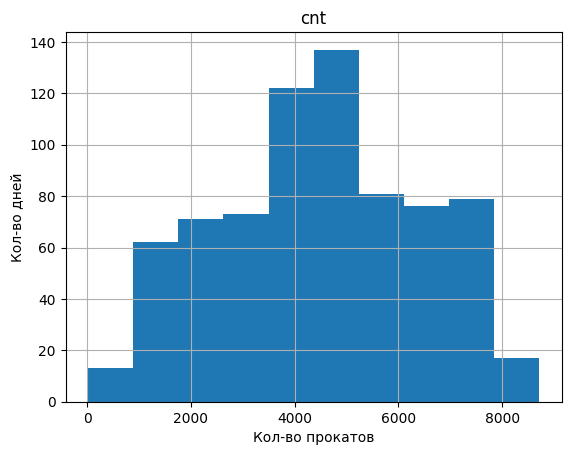

In [39]:
ax = df.hist('cnt')
plt.ylabel('Кол-во дней')
plt.xlabel('Кол-во прокатов')
plt.show()


**Ответьте на вопрос:** основываясь на графике, сколько приблизительно в среднем прокатов бывает в день?

Ответ: Прокатов в день бывает около 4-5тыс

### 6. Совместное распределение признаков

Постройте график совместного распределения признаков температура и ощущение температуры.



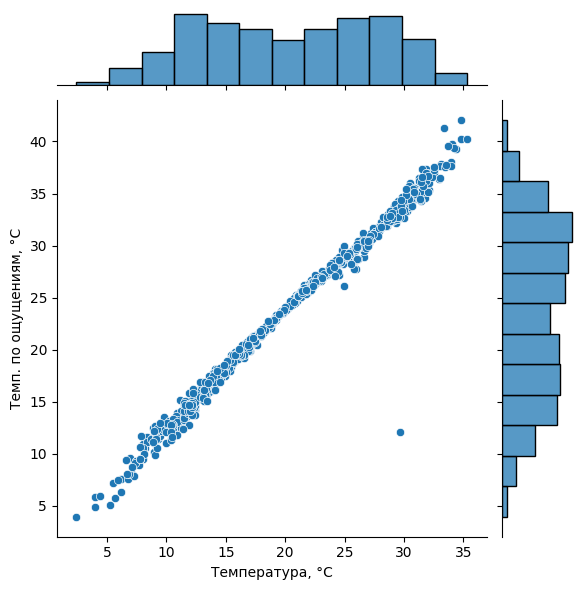

In [40]:
sns.jointplot(x='temp', y='atemp', data=df)
plt.xlabel('Температура, °C')
plt.ylabel('Темп. по ощущениям, °C')
plt.show()

**Ответьте на вопрос:** вас в этом графике ничего не настораживает? Почему?

Ответ: Одно из значений: температура была окло 30 градусов, а по ощущениям около 13-14 градусов. Скорее всего просто ввели неверные значения

### 7. Боксплот (ящик с усами)

Постройте график распределения (боксплот) количества прокатов велосипедов по месяцам в зависимости от того рабочий это день или нет.




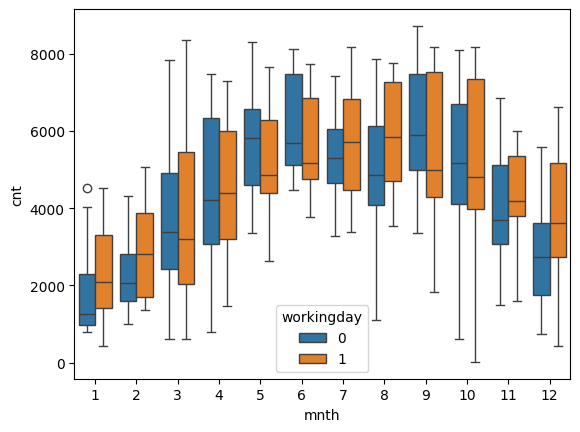

In [8]:
sns.boxplot(data=df, x='mnth', y='cnt', hue='workingday')
plt.show()

**Ответьте на вопрос:** почему в некоторых месяцах чаще берут велосипеды в будний день, а в некоторые - в выходной.

Ответ: Летом в выходные дни люди уезжают куда-то или чаще остаются дома и из-за этого реже берут напрокат велосипеды. В другие месяцы спрос больше из-за большего количества людей в городе или в месте где выдают велосипеды напрокат

## Комплексное задание №3. Визуальный анализ данных. Часть 2

In [44]:
# !pip install seaborn==0.11.0
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

В этом задании Вам предлагается провести визуальный анализ датасета результатов экзаменов студентов  https://www.kaggle.com/spscientist/students-performance-in-exams.

Исходные данные загрузите самостоятельно!

In [43]:
import kagglehub
path = kagglehub.dataset_download("spscientist/students-performance-in-exams")
df = pd.read_csv('/kaggle/input/students-performance-in-exams/StudentsPerformance.csv')
df.head()

Using Colab cache for faster access to the 'students-performance-in-exams' dataset.


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


### Ход задания:

#### 1. Постройте 3 графика, показывающих распределение результатов экзаменов (каждый график на предмет).


Графики должны быть в одном ряду и у них должен быть общий заголовок "Результаты экзаменов".

Для результатов каждого экзамена посчитайте медианные значения.


Математика медиана: 66.0
Письмо медиана: 69.0
Чтение медиана: 70.0


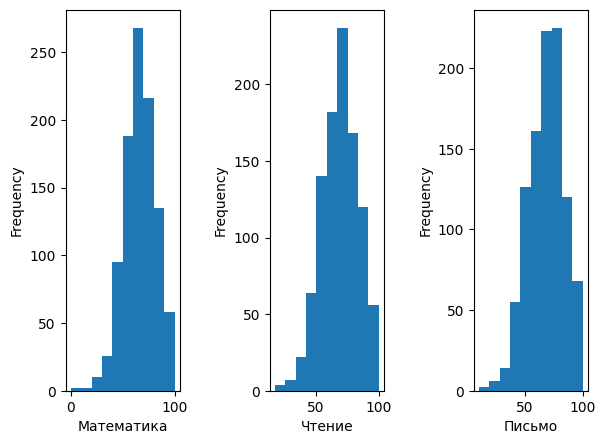

In [45]:
fig, ax = plt.subplots(1, 3)
df['math score'].plot(kind='hist', ax=ax[0], xlabel='Математика')
df['writing score'].plot(kind='hist', ax=ax[2], xlabel='Письмо')
df['reading score'].plot(kind='hist', ax=ax[1], xlabel='Чтение')
fig.tight_layout(pad=2.0)

print(f"Математика медиана: {df['math score'].agg('median')}")
print(f"Письмо медиана: {df['writing score'].agg('median')}")
print(f"Чтение медиана: {df['reading score'].agg('median')}")
plt.show()

#### 2. Образование родителей
Какие уровни образование есть в столбце *'parental level of education'* и сколько строк в датафрейме соответствует каждому уровню?

Постройте график и ответьте на вопрос ниже

Отличаются ли баллы по математике у детей с разным образованием родителей?
Постройте график, где по оси Х находятся уровни образования родителей, а по У - баллы по математике.

Ответ: Отличаются, но не очень сильно



parental level of education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64


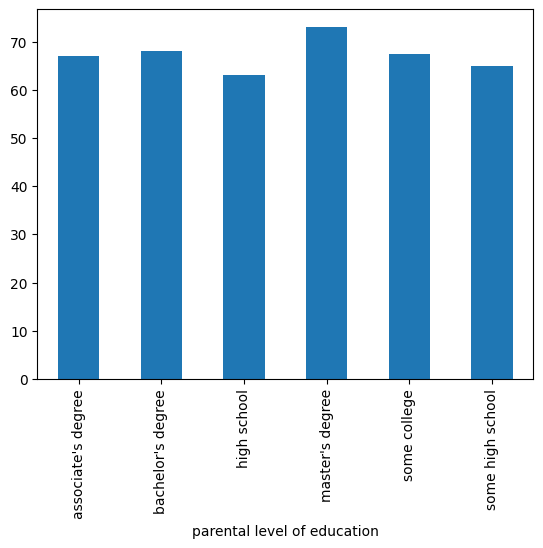

In [46]:
print(df['parental level of education'].value_counts())
df.groupby('parental level of education')['math score'].median().plot(kind='bar')
plt.show()

#### 3. Выведите число студенток, набравших больше 90 баллов по всем предметам.


In [47]:
df_f = df[df['gender'] == 'female']
df_f[(df_f['math score'] > 90 ) & (df_f['reading score'] > 90) & (df_f['writing score'] > 90)].size

136

#### 4. Сравните баллы у студентов разных полов. Используя agg() выведите минимальное, максимальное и медианное значение


In [48]:
df['sum score'] = df['math score']+df['writing score']+df['reading score']

print('Суммарно: ')
print(df.groupby('gender')['sum score'].agg('min'))
print(df.groupby('gender')['sum score'].agg('max'))
print(df.groupby('gender')['sum score'].agg('median'))

print('\nМатематика: ')
print(df.groupby('gender')['math score'].agg('min'))
print(df.groupby('gender')['math score'].agg('max'))
print(df.groupby('gender')['math score'].agg('median'))

print('\nПисьмо: ')
print(df.groupby('gender')['writing score'].agg('min'))
print(df.groupby('gender')['writing score'].agg('max'))
print(df.groupby('gender')['writing score'].agg('median'))

print('\nЧтение: ')
print(df.groupby('gender')['reading score'].agg('min'))
print(df.groupby('gender')['reading score'].agg('max'))
print(df.groupby('gender')['reading score'].agg('median'))

Суммарно: 
gender
female    27
male      69
Name: sum score, dtype: int64
gender
female    300
male      300
Name: sum score, dtype: int64
gender
female    211.0
male      199.0
Name: sum score, dtype: float64

Математика: 
gender
female     0
male      27
Name: math score, dtype: int64
gender
female    100
male      100
Name: math score, dtype: int64
gender
female    65.0
male      69.0
Name: math score, dtype: float64

Письмо: 
gender
female    10
male      15
Name: writing score, dtype: int64
gender
female    100
male      100
Name: writing score, dtype: int64
gender
female    74.0
male      64.0
Name: writing score, dtype: float64

Чтение: 
gender
female    17
male      23
Name: reading score, dtype: int64
gender
female    100
male      100
Name: reading score, dtype: int64
gender
female    73.0
male      66.0
Name: reading score, dtype: float64


#### 5. Выясните, влияет ли обед и подготовка к тесту на средний балл студентов разного пола
###### (подсказка: используете  [pd.agg()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.agg.html))

Ответ: Влияет. У кого бесплатная еда и кто не проходил тест - меньше баллов. Кто проходил и имел еду - больше баллов

In [49]:
df.groupby(['gender', 'lunch', 'test preparation course'])[['math score', 'reading score', 'writing score']].agg('mean')

math score  reading score  \
gender lunch        test preparation course                              
female free/reduced completed                 60.785714      73.428571   
                    none                      52.890756      63.831933   
       standard     completed                 71.131579      79.798246   
                    none                      66.530233      73.386047   
male   free/reduced completed                 65.639344      65.786885   
                    none                      60.609524      59.076190   
       standard     completed                 75.955752      72.601770   
                    none                      69.832512      64.719212   

                                             writing score  
gender lunch        test preparation course                 
female free/reduced completed                    74.371429  
                    none                         61.781513  
       standard     completed                    81.508772  
                    none                         72.967442  
male   free/reduced completed                    65.737705  
                    none                         55.285714  
       standard     completed                    71.982301  
                    none                         61.906404

#### 6. Постройте график, показывающий зависимость уровня образования родителей от их расы

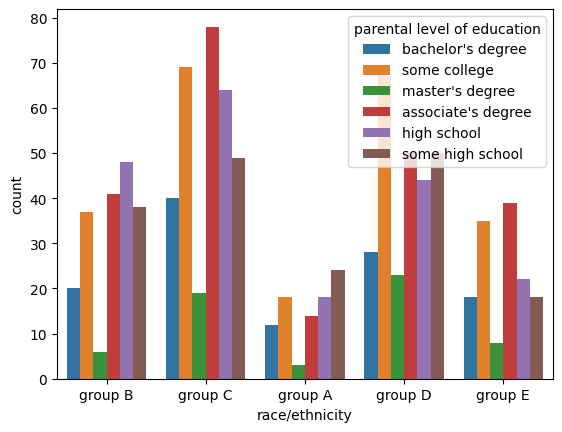

In [50]:
sns.countplot(df, x='race/ethnicity', hue='parental level of education')
plt.show()

#### 7. Постройте график, показывающий зависимость прохождения подготовительного теста от уровня образования родителей.


Кто чаще ходит на курсы: дети, родители которых закончили только старшую школу, или дети, чьи родители получили степень бакалавра\магистра?

Ответ: Чаще всего ходят дети у кого родители закончили старшую школу

<Axes: xlabel='parental level of education'>

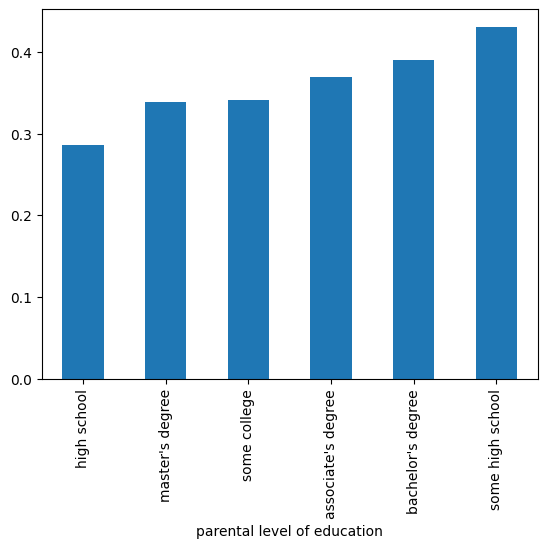

In [51]:
df['test completion'] = df['test preparation course'] == 'completed'
result = df.groupby('parental level of education')['test completion'].mean().sort_values()
result.plot(kind='bar')

#### 8. Постройте plot.pie, показывающий, сколько людей сдали\не сдали экзамен по математике.

Сдавшим считается человек, набравший 40 баллов.

###### Подсказка: создайте столбец в датафрейме, который содержит результат сдачи (сдал или не сдал)

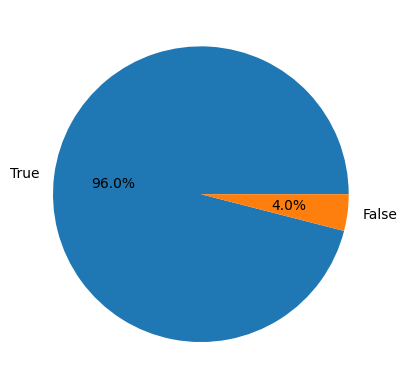

In [56]:
plt.pie(df['math pass'].value_counts(), labels=df['math pass'].unique(), autopct='%1.1f%%')
plt.show()

#### 9. Постройте plot.pie, показывающий распределение студентов по оценкам

Оценки студентов выставляются по шкале:<br>
0  - 40 marks : grade E<br>
41 - 60 marks : grade D<br>
60 - 70 marks : grade C<br>
70 - 80 marks : grade B<br>
80 - 90 marks : grade A<br>
90 - 100 marks : grade O<br>

Для этого посчитайте сумму результатов за 3 экзамена и найдите среднее. Оценка выставляется по среднему значению. Если студент не сдал математику(даже если средний балл выше 40), он получает Е

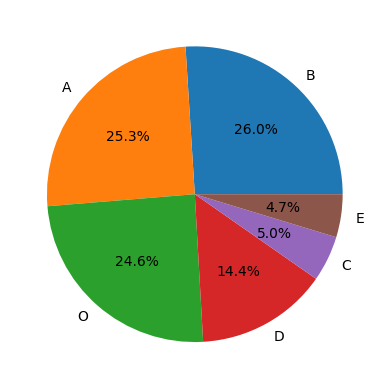

In [57]:
df['mean score'] = df[['math score', 'reading score', 'writing score']].mean(axis=1)
df['grade'] = pd.cut(df['mean score'],bins=[0, 40, 60, 70, 80, 90, 100],labels=['E', 'D', 'C', 'B', 'A', 'O'],include_lowest=True)
df.loc[df['math pass'] == False, 'grade'] = 'E'
plt.pie(df['grade'].value_counts(), labels=df['grade'].unique(), autopct='%1.1f%%')
plt.show()

#### 10. Постройте countplot, показывающий зависимость между итоговой оценкой студентов и его полом. Студенты какого пола получили больше оценок О, А, В

Ответ: Оценки О,А,В больше всего получили женский пол

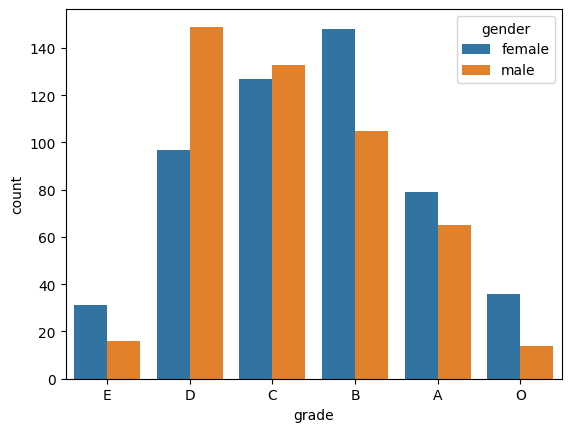

In [58]:
sns.countplot(df, x='grade', hue='gender')
plt.show()